# LSTM model with limited input

**Predict near-term volatility from historical return and volatility.**

Author: Pete King

This notebook uses financial data to train a univariate Long Short-Term Memory (LSTM) model to predict near-term volatility for a single ETF representing a market sector, using only the ETF's historical return and volatility as input.

The purpose of this notebook is to establish a baseline for an LSTM's ability to predict future volatility in a near-term outlook using limited input.  Subsequent LSTM models will incorporate additional features derived from macroeconomic data and market sentiment indicies.  We will compare performance of the models with limited vs. expanded input to asses the degree to which additional features help or hinder a model's ability to predict future financial performance.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

from helpers import data_prep as dp
from helpers import models

IMAGE_DIR = Path.cwd() / 'images'
DATA_DIR = Path.cwd().parent / 'data' / 'train-val-test'
TRAIN_DATA_FILE = DATA_DIR / 'train_etf_data.csv'
VAL_DATA_FILE = DATA_DIR / 'val_etf_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 10  # No. observations in each input sequence to LSTM
BATCH_SIZE = 21  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

We keep only return and historical volatility features for the asset in question.

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
data_cols = [TICKER + '_ret-h', TICKER + '_vol-h']
label_col = [TICKER + '_vol_target']
train_df[data_cols + label_col].head(SEQUENCE_LENGTH)

,SPY_ret-h,SPY_vol-h,SPY_vol_target
date,,,
2015-10-15,0.005650,0.007701,0.007586
2015-10-16,0.009590,0.007959,0.008211
2015-10-19,0.009138,0.007951,0.008211
2015-10-20,0.014181,0.007453,0.008897
2015-10-21,0.012764,0.007660,0.008794
2015-10-22,0.014279,0.008269,0.008038
2015-10-23,0.020644,0.009382,0.007682
2015-10-26,0.017692,0.009444,0.007668
2015-10-27,0.017037,0.009466,0.007657


In [3]:
val_df[data_cols + label_col]

,SPY_ret-h,SPY_vol-h,SPY_vol_target
date,,,
2023-01-03,-0.005473,0.010149,0.011025
2023-01-04,0.006169,0.010569,0.011143
2023-01-05,0.007196,0.010334,0.010940
2023-01-06,0.012028,0.012081,0.010161
2023-01-09,0.014099,0.012026,0.010439
...,...,...,...
2024-08-26,0.002107,0.006228,0.008510
2024-08-27,0.005106,0.006215,0.008549
2024-08-28,-0.004147,0.006562,0.008460


## II. PyTorch LSTM model implementation

### Create Datasets and DataLoaders

In this section we use the PyTorch library to create Datasets and DataLoaders that we will use to introduce training samples to the LSTM model in batches.

We use a custom Dataset for time series data.  The Dataset implements a rolling window that captures a series of data points from time (t - L) to time (t - 1), where L is the size of the rolling window (i.e., sequence length).  Thus each data sample is a matrix with dimensions (L, num_features), where 'num_features' is the number of features in each data instance.

In [4]:
X_train = train_df.dropna()[data_cols]
y_train = train_df.dropna()[label_col]
X_val = val_df.dropna()[data_cols]
y_val = val_df.dropna()[label_col]
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([10, 2])
Shape of first training label: torch.Size([1])


In [6]:
print(X_0)

tensor([[0.0056, 0.0077],
        [0.0096, 0.0080],
        [0.0091, 0.0080],
        [0.0142, 0.0075],
        [0.0128, 0.0077],
        [0.0143, 0.0083],
        [0.0206, 0.0094],
        [0.0177, 0.0094],
        [0.0170, 0.0095],
        [0.0346, 0.0104]])


In [7]:
print(y_0)

tensor([0.0073])


In [8]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([21, 10, 2])
Shape of first batch of labels: torch.Size([21, 1])


### Instantiate and train LSTM model

An important tunable hyperparameter for the LSTM is the size of the hidden layer.  A larger number of neurons will increase model complexity and could lead to overfitting, while too few neurons would increase the model's bias.  Considering the small number of input features, we use a relatively small hidden layer size.

Sequence length is another important hyperparameter.  We chose a sequence length of 10 to give our model two weeks (10 business days) worth of data, which should allow the model to learn recent trends in returns and volatility and perhaps learn relationships like, "several days of high returns leads to a period of high volatility," or "a spike in volatility tends to gradually decline over time towards the original baseline."

The ability of the LSTM to treat successive timestamps a dependent variables is a huge advantage over the Ridge and GBR models, which assume that all observations are independent of each other.

In [9]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 16  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [10]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [11]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(2, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


#### Loss function and Optimizer

The loss function and optimizer represent other hyperparameters we can tune for the LSTM model.  In undocumented tests, we explored the mean squared error loss function (MSELoss) and the root mean squared propagation (RMSprop) optimizer, but found the best results with the combinations below.

In [12]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [13]:
# Train and evaluate model
epochs = 1000
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')

Training model over 1000 epochs...
Epoch 100
Training loss:   0.00560291763395071
Validation loss: 0.007561469916254282
Epoch 200
Training loss:   0.0029669692739844322
Validation loss: 0.0050689298659563065
Epoch 300
Training loss:   0.001827719621360302
Validation loss: 0.0043358649127185345
Epoch 400
Training loss:   0.0012504486367106438
Validation loss: 0.004736362025141716
Epoch 500
Training loss:   0.0010580895468592644
Validation loss: 0.004179159179329872
Epoch 600
Training loss:   0.00010960735380649567
Validation loss: 0.003296693554148078
Epoch 700
Training loss:   0.0002337135374546051
Validation loss: 0.002642022678628564
Epoch 800
Training loss:   0.0002453560009598732
Validation loss: 0.002752147149294615
Epoch 900
Training loss:   0.0009992439299821854
Validation loss: 0.0038211606442928314
Epoch 1000
Training loss:   0.0007507279515266418
Validation loss: 0.0035754761192947626


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


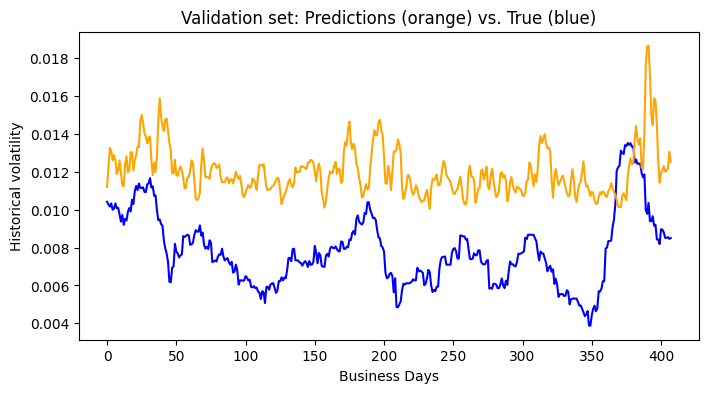

In [14]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Historical volatility')
ax.set_xlabel('Business Days')
ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')
fig.savefig(IMAGE_DIR / 'D-LSTM-limited')

In [15]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds))}')

R2: -4.685590744018555
MAE: 0.004302502144128084
RMSE: 0.0046026576310396194
MSE: 2.118445627274923e-05
